In [41]:
from sklearn.linear_model import Perceptron

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

In [42]:
from sklearn.datasets import load_iris

iris = load_iris()

df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target


df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [43]:
X=df_iris.iloc[:,[2,3]].values
y=df_iris.iloc[:,4].values

In [44]:
setosa_versicolor = (df_iris['target'] == 0) | (df_iris['target'] == 1)

#Variáveis do banco de dados:
#1.petal length in cm
#2. petal width in cm
#3. class
#Iris setosa (0)
#Versicolor (1)

In [45]:
modelo_per = Perceptron(max_iter=1000,tol=1e-3,random_state=42)
modelo_per.fit(X[setosa_versicolor],y[setosa_versicolor])

print("Perceptron treinado!!!")
print(f'Os pesos encontrados foram {modelo_per.coef_} e o bias {modelo_per.intercept_}')

Perceptron treinado!!!
Os pesos encontrados foram [[1.5 2.2]] e o bias [-5.]


In [46]:
w1,w2=modelo_per.coef_[0]
bias=modelo_per.intercept_[0]

print('w1: ',w1)
print('w2: ',w2)
print('bias:',bias)

w1:  1.5
w2:  2.1999999999999997
bias: -5.0


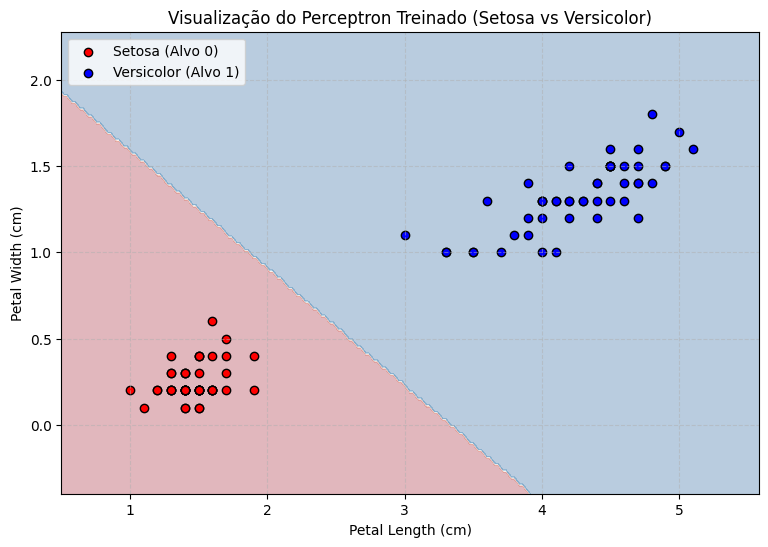

In [47]:


# 1. Preparando os dados filtrados (exatamente como no seu treino)
X_filtrado = X[setosa_versicolor]
y_filtrado = y[setosa_versicolor]

# 2. Criando uma grade de pontos para o fundo do gráfico
x_min, x_max = X_filtrado[:, 0].min() - 0.5, X_filtrado[:, 0].max() + 0.5
y_min, y_max = X_filtrado[:, 1].min() - 0.5, X_filtrado[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 3. Usando seu 'modelo_per' para prever a classe de cada ponto da grade
Z = modelo_per.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plotagem
plt.figure(figsize=(9, 6))

# Pinta as áreas de decisão (Fronteira)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

# Plota os dados reais fornecidos ao modelo
plt.scatter(X_filtrado[y_filtrado == 0, 0], X_filtrado[y_filtrado == 0, 1],
            c='red', edgecolors='k', label='Setosa (Alvo 0)')
plt.scatter(X_filtrado[y_filtrado == 1, 0], X_filtrado[y_filtrado == 1, 1],
            c='blue', edgecolors='k', label='Versicolor (Alvo 1)')

# Perfumaria (Legendas e Títulos)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Visualização do Perceptron Treinado (Setosa vs Versicolor)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()